<a href="https://colab.research.google.com/github/OscarPasasin/Parcial4-PasasinOscar-1704862022/blob/main/notebooks/CorrelacionClaveA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
#Ignorar advertencias
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://raw.githubusercontent.com/OscarPasasin/Parcial4-PasasinOscar-1704862022/refs/heads/main/Archivos/clave_A_correlacion.csv"
df = pd.read_csv(url)
df.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,A-C0001,37,468,4,36.45,8.73,1,7,22.02,297.03
1,A-C0002,27,1076,8,63.31,9.15,0,6,24.89,524.34
2,A-C0003,19,948,5,44.25,8.33,0,1,26.58,181.14
3,A-C0004,41,832,8,63.11,9.90,0,5,16.22,532.66
4,A-C0005,30,1287,6,86.49,7.83,1,4,20.42,557.44


In [4]:
df.info()
#Identificamos automáticamente las columnas numéricas (excluyendo IDs)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"variables numericas para el análisis{numeric_cols}")



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          221 non-null    object 
 1   edad                221 non-null    int64  
 2   ingresos_mensuales  221 non-null    int64  
 3   frecuencia_compra   221 non-null    int64  
 4   ticket_promedio     220 non-null    float64
 5   satisfaccion        220 non-null    float64
 6   reclamos            221 non-null    int64  
 7   uso_app             221 non-null    int64  
 8   tiempo_respuesta    220 non-null    float64
 9   consumo_total       221 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 17.4+ KB
variables numericas para el análisis['edad', 'ingresos_mensuales', 'frecuencia_compra', 'ticket_promedio', 'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta', 'consumo_total']


In [5]:
#Verificar nulos
print(df.isnull().sum())

#Verificar duplicados
n_duplicados = df.duplicated().sum()

#Limpieza de Consistencia
df_clean = df.drop_duplicates().copy()

#Tratamiento de nulos con la media para mantener consistencia estadistica
for col in ['ticket_promedio', 'satisfaccion', 'tiempo_respuesta']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

#Resumen estadístico para examinar valores atipicos
display(df_clean.describe())


cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64


,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
count,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.00000,220.000000,220.000000
mean,33.909091,855.345455,7.027273,55.168864,7.540545,1.559091,5.10000,21.954864,410.555591
std,10.001411,250.947845,3.050441,16.183012,1.160745,1.582195,1.93714,5.777941,175.852896
min,18.000000,300.000000,1.000000,14.660000,2.390000,0.000000,0.00000,9.260000,72.590000
25%,27.000000,693.500000,6.000000,42.662500,6.910000,1.000000,4.00000,17.710000,289.642500
50%,34.000000,855.000000,7.000000,55.490000,7.630000,1.000000,5.00000,21.590000,389.640000
75%,41.000000,1012.000000,8.000000,67.195000,8.312500,2.000000,6.00000,25.667500,504.695000
max,60.000000,1517.000000,27.000000,96.050000,9.900000,9.000000,10.00000,40.160000,1291.030000


In [6]:
matriz_corr = df_clean[numeric_cols].corr()
print("Matriz de correlacion")
display(matriz_corr.round(4))

Matriz de correlacion


,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.0000,0.0015,-0.0348,0.1323,-0.1042,0.0523,0.0321,0.0557,0.0613
ingresos_mensuales,0.0015,1.0000,0.0492,0.5592,-0.0041,0.0266,-0.0976,-0.0610,0.2980
frecuencia_compra,-0.0348,0.0492,1.0000,0.1037,0.2474,-0.1224,0.5737,-0.3296,0.8335
ticket_promedio,0.1323,0.5592,0.1037,1.0000,0.0684,-0.0578,0.0147,-0.1027,0.5513
satisfaccion,-0.1042,-0.0041,0.2474,0.0684,1.0000,-0.7722,0.0968,-0.5457,0.3281
reclamos,0.0523,0.0266,-0.1224,-0.0578,-0.7722,1.0000,0.0815,0.4741,-0.2095
uso_app,0.0321,-0.0976,0.5737,0.0147,0.0968,0.0815,1.0000,-0.2566,0.5420
tiempo_respuesta,0.0557,-0.0610,-0.3296,-0.1027,-0.5457,0.4741,-0.2566,1.0000,-0.3783
consumo_total,0.0613,0.2980,0.8335,0.5513,0.3281,-0.2095,0.5420,-0.3783,1.0000


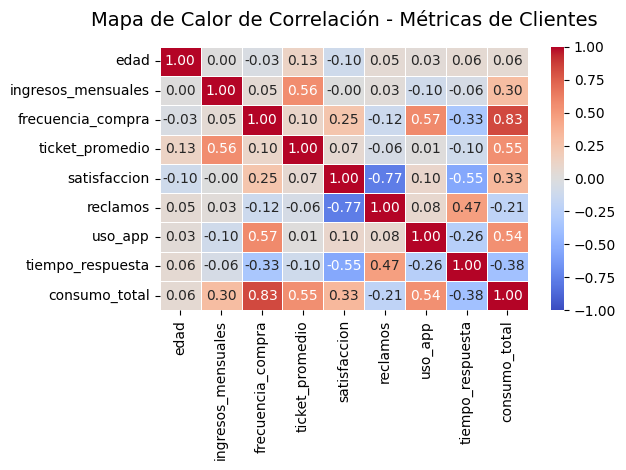

In [8]:
#Generamos mapa de calor
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Mapa de Calor de Correlación - Métricas de Clientes', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [9]:
#Desapilamos la matriz para extraer los pares de variables ordenados
corr_flat = matriz_corr.unstack().sort_values(ascending=False)
corr_flat = corr_flat[corr_flat != 1.0] # Filtramos la autocorrelación de 1.0

print("CORRELACIONES POSITIVAS MÁS IMPORTANTES")
print(corr_flat.drop_duplicates().head(3))

print("CORRELACIONES NEGATIVAS MÁS IMPORTANTES")
print(corr_flat.drop_duplicates().tail(3))

CORRELACIONES POSITIVAS MÁS IMPORTANTES
frecuencia_compra  consumo_total         0.833482
                   uso_app               0.573681
ticket_promedio    ingresos_mensuales    0.559181
dtype: float64
CORRELACIONES NEGATIVAS MÁS IMPORTANTES
consumo_total     tiempo_respuesta   -0.378252
tiempo_respuesta  satisfaccion       -0.545660
satisfaccion      reclamos           -0.772223
dtype: float64
